In [ ]:
import sys
import os

# Add the parent directory to the path so we can import src
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np

# Import your code
from src.env import TrafficEnv
from src.baseline import FixedTimeAgent
from src.agent import QLearningAgent
from src.config import MODELS_DIR

print("Libraries loaded successfully!")


Libraries loaded successfully!


Simulation finished after 201 steps.


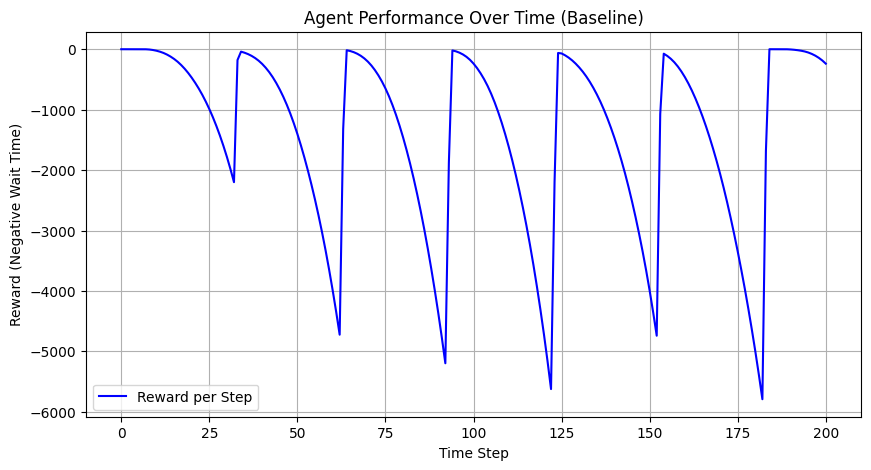

In [21]:
# 1. Setup
env = TrafficEnv()
agent = FixedTimeAgent(cycle_duration=30)

# 2. Storage for plotting
queues_over_time = []
rewards_over_time = []

# 3. Run one episode
obs, info = env.reset()
done = False
truncated = False
step = 0

while not (done or truncated):
    action = agent.act(obs)
    obs, reward, done, truncated, info = env.step(action)
    
    # Store data for plotting
    # Note: Since env logic isn't finished, rewards are 0.
    # Once car locig pushed, this graph will become real.
    rewards_over_time.append(reward)
    
    # Let's assume obs[1] and obs[2] are the queue buckets (NS and EW)
    # We save them to visualize congestion
    queues_over_time.append((obs[1], obs[2]))
    
    step += 1
    if step > 200: break # testing

print(f"Simulation finished after {step} steps.")

# 4. Plotting
plt.figure(figsize=(10, 5))
plt.plot(rewards_over_time, label="Reward per Step", color='blue')
plt.title("Agent Performance Over Time (Baseline)")
plt.xlabel("Time Step")
plt.ylabel("Reward (Negative Wait Time)")
plt.legend()
plt.grid(True)
plt.show()


Trained agent: simulation finished after 201 steps. Total reward: -46573.000


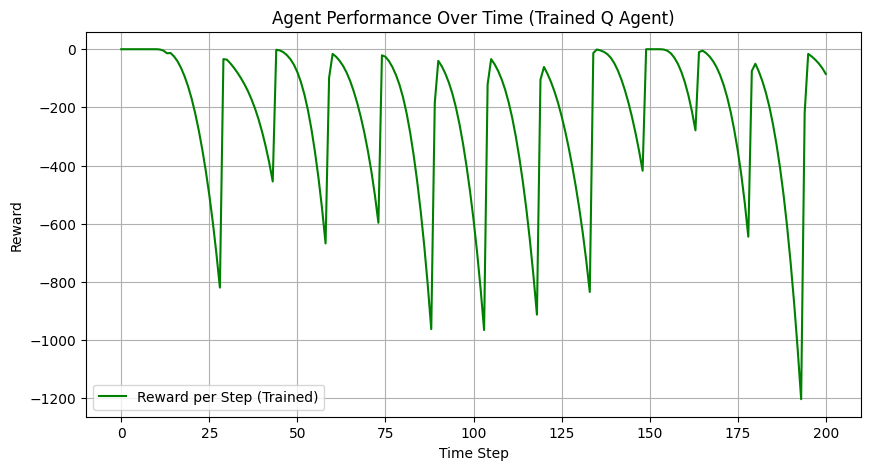

In [ ]:
# Compare with trained Q agent

from src.env import TrafficEnv
from src.agent import QLearningAgent
from src.config import MODELS_DIR

# 1) Setup
env_tr = TrafficEnv()
state_dim_tr = tuple(env_tr.observation_space.nvec.tolist())
action_dim_tr = int(env_tr.action_space.n)
agent_tr = QLearningAgent(state_dim_tr, action_dim_tr, epsilon=0.0)
agent_tr.load(os.path.join(MODELS_DIR, "q_table.npy"))

# 2) Storage for plotting
rewards_over_time_trained = []
queues_over_time_trained = []

# 3) Run one episode
obs, info = env_tr.reset()
done = False
truncated = False
step = 0

while not (done or truncated):
    action = agent_tr.act(obs, explore=False)
    obs, reward, done, truncated, info = env_tr.step(action)

    rewards_over_time_trained.append(reward)
    queues_over_time_trained.append((int(obs[1]), int(obs[2])))

    step += 1
    if step > 200:
        break

print(f"Trained agent: simulation finished after {step} steps. Total reward: {sum(rewards_over_time_trained):.3f}")

# 4) Plotting
plt.figure(figsize=(10, 5))
plt.plot(rewards_over_time_trained, label="Reward per Step (Trained)", color='green')
plt.title("Agent Performance Over Time (Trained Q Agent)")
plt.xlabel("Time Step")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()

Baseline total reward: -218569.000 over 201 steps
Trained   total reward: -46916.000 over 201 steps


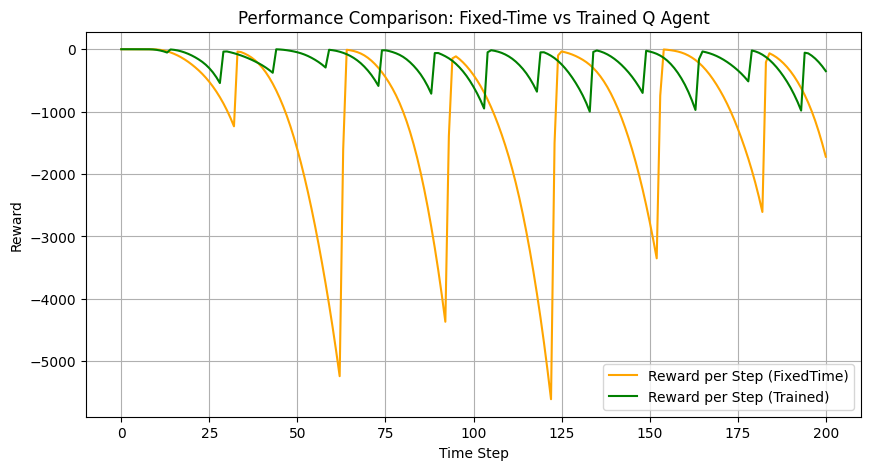

In [ ]:
# Side-by-side comparison: FixedTime vs Trained Q Agent
import sys, os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np

from src.env import TrafficEnv
from src.baseline import FixedTimeAgent
from src.agent import QLearningAgent
from src.config import MODELS_DIR

# Baseline run
env_b = TrafficEnv()
agent_b = FixedTimeAgent(cycle_duration=30)

obs_b, info_b = env_b.reset()
done_b = False
trunc_b = False
rewards_b = []
steps_b = 0

while not (done_b or trunc_b):
    action_b = agent_b.act(obs_b)
    obs_b, reward_b, done_b, trunc_b, info_b = env_b.step(action_b)
    rewards_b.append(reward_b)
    steps_b += 1
    if steps_b > 200:
        break

# Trained run
env_t = TrafficEnv()
state_dim_t = tuple(env_t.observation_space.nvec.tolist())
action_dim_t = int(env_t.action_space.n)
agent_t = QLearningAgent(state_dim_t, action_dim_t, epsilon=0.0)
agent_t.load(os.path.join(MODELS_DIR, "q_table.npy"))

obs_t, info_t = env_t.reset()
done_t = False
trunc_t = False
rewards_t = []
steps_t = 0

while not (done_t or trunc_t):
    action_t = agent_t.act(obs_t, explore=False)
    obs_t, reward_t, done_t, trunc_t, info_t = env_t.step(action_t)
    rewards_t.append(reward_t)
    steps_t += 1
    if steps_t > 200:
        break

print(f"Baseline total reward: {sum(rewards_b):.3f} over {len(rewards_b)} steps")
print(f"Trained   total reward: {sum(rewards_t):.3f} over {len(rewards_t)} steps")

# Plot both curves
plt.figure(figsize=(10, 5))
plt.plot(rewards_b, label="Reward per Step (FixedTime)", color='orange')
plt.plot(rewards_t, label="Reward per Step (Trained)", color='green')
plt.title("Performance Comparison: Fixed-Time vs Trained Q Agent")
plt.xlabel("Time Step")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()